In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams.update({'font.size': 12, 'figure.figsize': (12, 6)})

print("Libraries successfully imported!")

Matplotlib is building the font cache; this may take a moment.


Libraries successfully imported!


In [3]:
# Define paths relative to the /ml/notebooks/ directory
metadata_path = '/Users/shivanshuprakash/Desktop/EV/ml/data/metadata.csv'

if os.path.exists(metadata_path):
    metadata_df = pd.read_csv(metadata_path)
    print(f"Metadata loaded successfully! Total records: {len(metadata_df)}")
    print("\n--- First 5 Rows of Metadata ---")
    display(metadata_df.head())
    
    print("\n--- Dataset Info ---")
    metadata_df.info()
else:
    print(f"ERROR: Could not find metadata file at {metadata_path}. Check your file structure!")

Metadata loaded successfully! Total records: 7565

--- First 5 Rows of Metadata ---


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   type                 7565 non-null   str  
 1   start_time           7565 non-null   str  
 2   ambient_temperature  7565 non-null   int64
 3   battery_id           7565 non-null   str  
 4   test_id              7565 non-null   int64
 5   uid                  7565 non-null   int64
 6   filename             7565 non-null   str  
 7   Capacity             2794 non-null   str  
 8   Re                   1956 non-null   str  
 9   Rct                  1956 non-null   str  
dtypes: int64(3), str(7)
memory usage: 591.1 KB


In [5]:
# Force the Capacity column to be actual numbers (floats) before splitting
metadata_df['Capacity'] = pd.to_numeric(metadata_df['Capacity'], errors='coerce')

# Filter metadata for battery B0005 during discharge operations
b0005_discharge = metadata_df[(metadata_df['battery_id'] == 'B0005') & (metadata_df['type'] == 'discharge')].copy()
b0005_discharge['cycle_index'] = range(1, len(b0005_discharge) + 1)

# Step 1: Establish the baseline nominal capacity from the very first discharge cycle
initial_capacity = b0005_discharge['Capacity'].iloc[0]
eol_threshold = initial_capacity * 0.70  # Now this math will work perfectly!

print(f"Initial Nominal Capacity for B0005: {initial_capacity:.4f} Ah")
print(f"Automotive End-of-Life (EOL) Threshold (70% SoH): {eol_threshold:.4f} Ah")

# Find the exact cycle where it drops below EOL
eol_cycles = b0005_discharge[b0005_discharge['Capacity'] <= eol_threshold]
if not eol_cycles.empty:
    first_eol_cycle = eol_cycles['cycle_index'].iloc[0]
    print(f"\n🔥 Critical Insight: Battery B0005 hits automotive EOL at Cycle #{first_eol_cycle}")
else:
    print("\n🔋 Battery did not degrade past 70% in this test window.")

Initial Nominal Capacity for B0005: 1.8565 Ah
Automotive End-of-Life (EOL) Threshold (70% SoH): 1.2995 Ah

🔥 Critical Insight: Battery B0005 hits automotive EOL at Cycle #162


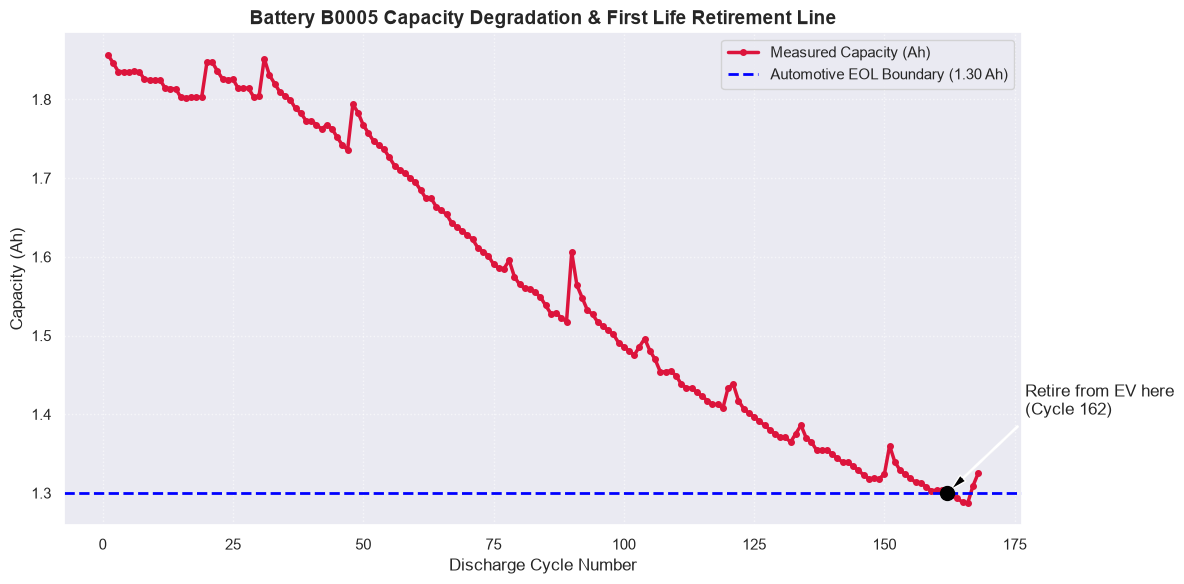

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(b0005_discharge['cycle_index'], b0005_discharge['Capacity'], 
         color='crimson', linewidth=2.5, marker='o', markersize=4, label='Measured Capacity (Ah)')

# Draw the 70% EOL boundary line
plt.axhline(y=eol_threshold, color='blue', linestyle='--', linewidth=2, 
            label=f'Automotive EOL Boundary ({eol_threshold:.2f} Ah)')

# Annotate the exact EOL point if found
if not eol_cycles.empty:
    plt.scatter(first_eol_cycle, eol_threshold, color='black', s=100, zorder=5)
    plt.annotate(f'Retire from EV here\n(Cycle {first_eol_cycle})', 
                 xy=(first_eol_cycle, eol_threshold), 
                 xytext=(first_eol_cycle + 15, eol_threshold + 0.1),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.title('Battery B0005 Capacity Degradation & First Life Retirement Line', fontsize=14, fontweight='bold')
plt.xlabel('Discharge Cycle Number', fontsize=12)
plt.ylabel('Capacity (Ah)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Targeting Granular Data File Path: ../data/05122.csv

--- Granular Telemetry Sensor Profiles ---


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.191492,-0.004902,24.330034,-0.0006,0.000,0.000
1,4.190749,-0.001478,24.325993,-0.0006,4.206,16.781
2,3.974871,-2.012528,24.389085,-1.9982,3.062,35.703
3,3.951717,-2.013979,24.544752,-1.9982,3.030,53.781
4,3.934352,-2.011144,24.731385,-1.9982,3.011,71.922


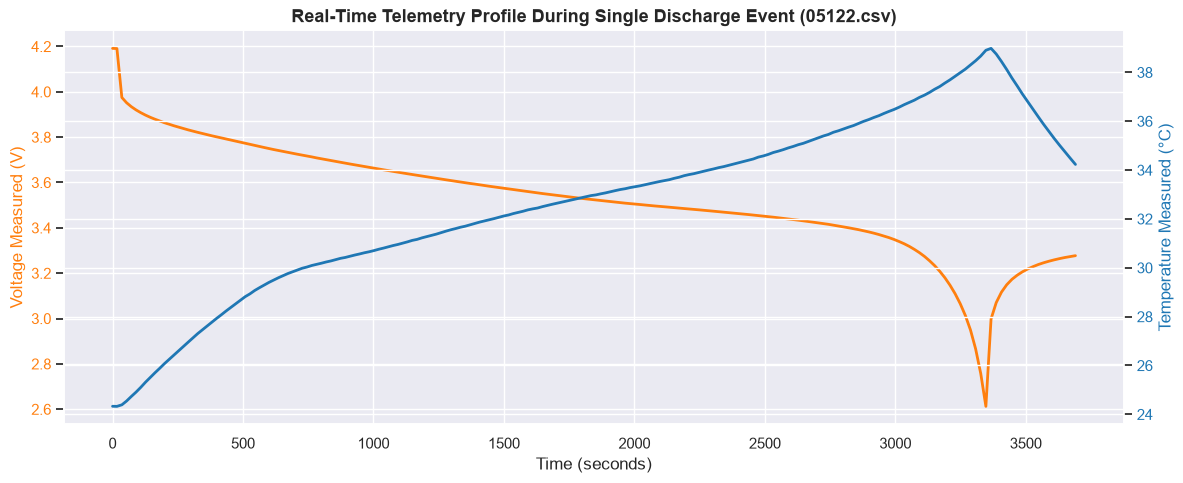

In [8]:
import os

# 1. Grab the filename from the metadata row
sample_file_name = b0005_discharge['filename'].iloc[0]

# 2. FIX: Point directly to '../data/' instead of '../data/data/' 
# and strip any potential mismatched padding issues if necessary.
sample_file_path = f'../data/{sample_file_name}'

print(f"Targeting Granular Data File Path: {sample_file_path}")

if os.path.exists(sample_file_path):
    # Load that specific cycle's internal telemetry log
    cycle_telemetry_df = pd.read_csv(sample_file_path)
    
    print("\n--- Granular Telemetry Sensor Profiles ---")
    display(cycle_telemetry_df.head())
    
    # 3. Plot how Voltage and Temperature behave dynamically during this single cycle
    fig, ax1 = plt.subplots(figsize=(12, 5))

    color = 'tab:orange'
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Voltage Measured (V)', color=color)
    ax1.plot(cycle_telemetry_df['Time'], cycle_telemetry_df['Voltage_measured'], color=color, linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)

    # Create a secondary Y-axis on the right side for temperature
    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('Temperature Measured (°C)', color=color)
    ax2.plot(cycle_telemetry_df['Time'], cycle_telemetry_df['Temperature_measured'], color=color, linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Real-Time Telemetry Profile During Single Discharge Event ({sample_file_name})', fontsize=13, fontweight='bold')
    fig.tight_layout()
    plt.show()
else:
    print(f"ERROR: Missing file at {sample_file_path}.")
    print("Let's debug! Let's see the first few files actually available in your directory:")
    try:
        print(os.listdir('../data/')[:10])
    except Exception as e:
        print(f"Could not read directory: {e}")